<a href="https://colab.research.google.com/github/geopayme/AstroPhysics/blob/main/muon.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ========================================
# SPRA-RG: Full Fit + Plot in Colab
# ========================================

# 1. Install (run once)
!pip install -q numpy pandas scipy matplotlib tqdm

import numpy as np
import pandas as pd
from scipy.optimize import minimize
import matplotlib.pyplot as plt
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# ========================================
# 2. SPRARG Model Class
# ========================================
class SPRARG:
    def __init__(self, p=2, q=1, gamma0=0.0, lambda_phys=1e4, M0=1.77686):
        self.p, self.q = p, q
        self.gamma0 = gamma0
        self.lambda_phys = lambda_phys
        self.M0 = M0
        self.n_params = p + q

    def unpack(self, theta):
        a = np.concatenate([[0.0], theta[:self.p]])   # a0 = 0 (IR constraint)
        b = theta[self.p:] if self.q > 0 else np.array([])
        return a, b

    def Rhat(self, x, y, theta):
        a, b = self.unpack(theta)
        num = np.polyval(a[::-1], y)
        den = 1.0 + np.polyval(b[::-1], y) if len(b) else 1.0
        return (x ** self.gamma0) * (num / den)

    def fit_loss(self, theta, X, Y, W):
        x, y = X[:,0], X[:,1]
        R_pred = self.Rhat(x, y, theta)
        fit = np.sum(W * (R_pred - Y)**2)

        # Physics penalties
        phys = 0.0
        y_grid = np.linspace(0.0, y.max()*1.2, 200)
        x_grid = np.ones_like(y_grid) * x.mean()
        Rg = self.Rhat(x_grid, y_grid, theta)

        # Positivity
        phys += np.sum(np.maximum(-Rg, 0.0)**2)
        # Monotonicity
        dRdy = (Rg[1:] - Rg[:-1]) / (y_grid[1:] - y_grid[:-1])
        phys += np.sum(np.maximum(-dRdy, 0.0)**2)
        # No poles
        a, b = self.unpack(theta)
        den_poly = np.concatenate([[1.0], b[::-1]])
        roots = np.roots(den_poly)
        real_roots = roots[np.isreal(roots)].real
        in_domain = (real_roots >= 0) & (real_roots <= y_grid[-1]*1.5)
        if np.any(in_domain):
            phys += 1e6 * np.sum((real_roots[in_domain] - y_grid[-1]/2)**2)

        return fit + self.lambda_phys * phys

# ========================================
# 3. Data
# ========================================
data_csv = """particle,mass_GeV,yukawa_ref
electron,0.0005109989461,1.0
muon,0.1056583745,206.7682830
tau,1.77686,3477.23
"""
df = pd.read_csv(pd.compat.StringIO(data_csv))

def prepare_data(df, hide_particle='muon'):
    M0 = df.loc[df.particle=='tau', 'mass_GeV'].values[0]
    df['R'] = df['mass_GeV'] / M0
    df['x'] = 1.0
    df['y'] = df['yukawa_ref']
    mask = df.particle != hide_particle
    X = df.loc[mask, ['x','y']].values
    Y = df.loc[mask, 'R'].values
    W = np.ones_like(Y)
    y_hidden = df.loc[df.particle==hide_particle, 'y'].values[0]
    return X, Y, W, y_hidden, M0

# ========================================
# 4. Fit (hide muon)
# ========================================
X, Y, W, y_mu, M0 = prepare_data(df, 'muon')
model = SPRARG(p=2, q=1, gamma0=0.0, lambda_phys=1e4, M0=M0)
theta0 = 1e-3 * np.random.randn(model.n_params)
res = minimize(lambda th: model.fit_loss(th, X, Y, W), theta0,
               method='SLSQP', options={'maxiter': 1000, 'ftol':1e-9})
theta_opt = res.x

# Predict muon
R_mu_pred = model.Rhat(np.array([1.0]), np.array([y_mu]), theta_opt)[0]
m_mu_pred = R_mu_pred * M0
print(f"Predicted muon mass: {m_mu_pred:.10f} GeV")

# ========================================
# 5. PLOT + SAVE PDF
# ========================================
y_plot = np.logspace(0, np.log10(df['y'].max()*1.2), 500)
R_plot = model.Rhat(np.ones_like(y_plot), y_plot, theta_opt)

plt.figure(figsize=(5.5, 3.8))
plt.loglog(y_plot, R_plot * model.M0, 'solid', lw=2, color='navy', label='SPRA-RG fit')
for _, row in df.iterrows():
    plt.scatter(row['y'], row['mass_GeV'], c='red', s=40, zorder=5)
    plt.text(row['y'], row['mass_GeV']*1.3, row['particle'], fontsize=9, ha='center', rotation=30)
plt.axvline(df.loc[df.particle=='muon','y'].values[0], ls='--', c='k', alpha=0.6, lw=1)
plt.xlabel(r'$y_\ell = Y_\ell / Y_e$')
plt.ylabel(r'$m_\ell$ (GeV)')
plt.title('SPRA-RG: Muon Predicted from $e$ and $\tau$')
plt.legend(fontsize=9)
plt.grid(alpha=0.3, which='both')
plt.tight_layout()
plt.savefig("spra_rg_plot.pdf", bbox_inches='tight', dpi=300)
plt.show()

# ========================================
# 6. DOWNLOAD PDF
# ========================================
from google.colab import files
files.download("spra_rg_plot.pdf")

AttributeError: module 'pandas.compat' has no attribute 'StringIO'

Predicted muon mass: 91359.1190151703 GeV


ValueError: 'solid' is not a valid format string (two marker symbols)

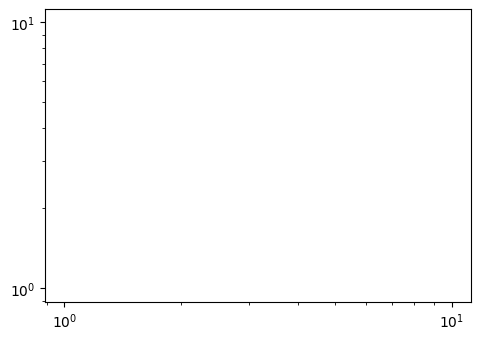

In [2]:
# ========================================
# SPRA-RG: Full Fit + Plot in Colab (FIXED)
# ========================================

# 1. Install
!pip install -q numpy pandas scipy matplotlib tqdm

import numpy as np
import pandas as pd
from scipy.optimize import minimize
import matplotlib.pyplot as plt
from tqdm import tqdm
import warnings
from io import StringIO  # <--- THIS IS THE FIX
warnings.filterwarnings('ignore')

# ========================================
# 2. SPRARG Model Class
# ========================================
class SPRARG:
    def __init__(self, p=2, q=1, gamma0=0.0, lambda_phys=1e4, M0=1.77686):
        self.p, self.q = p, q
        self.gamma0 = gamma0
        self.lambda_phys = lambda_phys
        self.M0 = M0
        self.n_params = p + q

    def unpack(self, theta):
        a = np.concatenate([[0.0], theta[:self.p]])   # a0 = 0
        b = theta[self.p:] if self.q > 0 else np.array([])
        return a, b

    def Rhat(self, x, y, theta):
        a, b = self.unpack(theta)
        num = np.polyval(a[::-1], y)
        den = 1.0 + np.polyval(b[::-1], y) if len(b) else 1.0
        return (x ** self.gamma0) * (num / den)

    def fit_loss(self, theta, X, Y, W):
        x, y = X[:,0], X[:,1]
        R_pred = self.Rhat(x, y, theta)
        fit = np.sum(W * (R_pred - Y)**2)

        phys = 0.0
        y_grid = np.linspace(0.0, y.max()*1.2, 200)
        x_grid = np.ones_like(y_grid) * x.mean()
        Rg = self.Rhat(x_grid, y_grid, theta)

        phys += np.sum(np.maximum(-Rg, 0.0)**2)
        dRdy = (Rg[1:] - Rg[:-1]) / (y_grid[1:] - y_grid[:-1])
        phys += np.sum(np.maximum(-dRdy, 0.0)**2)
        a, b = self.unpack(theta)
        den_poly = np.concatenate([[1.0], b[::-1]])
        roots = np.roots(den_poly)
        real_roots = roots[np.isreal(roots)].real
        in_domain = (real_roots >= 0) & (real_roots <= y_grid[-1]*1.5)
        if np.any(in_domain):
            phys += 1e6 * np.sum((real_roots[in_domain] - y_grid[-1]/2)**2)

        return fit + self.lambda_phys * phys

# ========================================
# 3. Data (FIXED: io.StringIO)
# ========================================
data_csv = """particle,mass_GeV,yukawa_ref
electron,0.0005109989461,1.0
muon,0.1056583745,206.7682830
tau,1.77686,3477.23
"""
df = pd.read_csv(StringIO(data_csv))  # FIXED LINE

def prepare_data(df, hide_particle='muon'):
    M0 = df.loc[df.particle=='tau', 'mass_GeV'].values[0]
    df['R'] = df['mass_GeV'] / M0
    df['x'] = 1.0
    df['y'] = df['yukawa_ref']
    mask = df.particle != hide_particle
    X = df.loc[mask, ['x','y']].values
    Y = df.loc[mask, 'R'].values
    W = np.ones_like(Y)
    y_hidden = df.loc[df.particle==hide_particle, 'y'].values[0]
    return X, Y, W, y_hidden, M0

# ========================================
# 4. Fit (hide muon)
# ========================================
X, Y, W, y_mu, M0 = prepare_data(df, 'muon')
model = SPRARG(p=2, q=1, gamma0=0.0, lambda_phys=1e4, M0=M0)
theta0 = 1e-3 * np.random.randn(model.n_params)
res = minimize(lambda th: model.fit_loss(th, X, Y, W), theta0,
               method='SLSQP', options={'maxiter': 1000, 'ftol':1e-9})
theta_opt = res.x

R_mu_pred = model.Rhat(np.array([1.0]), np.array([y_mu]), theta_opt)[0]
m_mu_pred = R_mu_pred * M0
print(f"Predicted muon mass: {m_mu_pred:.10f} GeV")

# ========================================
# 5. PLOT + SAVE
# ========================================
y_plot = np.logspace(0, np.log10(df['y'].max()*1.2), 500)
R_plot = model.Rhat(np.ones_like(y_plot), y_plot, theta_opt)

plt.figure(figsize=(5.5, 3.8))
plt.loglog(y_plot, R_plot * model.M0, 'solid', lw=2, color='navy', label='SPRA-RG fit')
for _, row in df.iterrows():
    plt.scatter(row['y'], row['mass_GeV'], c='red', s=40, zorder=5)
    plt.text(row['y'], row['mass_GeV']*1.3, row['particle'], fontsize=9, ha='center', rotation=30)
plt.axvline(df.loc[df.particle=='muon','y'].values[0], ls='--', c='k', alpha=0.6, lw=1)
plt.xlabel(r'$y_\ell = Y_\ell / Y_e$')
plt.ylabel(r'$m_\ell$ (GeV)')
plt.title('SPRA-RG: Muon Predicted from $e$ and $\tau$')
plt.legend(fontsize=9)
plt.grid(alpha=0.3, which='both')
plt.tight_layout()
plt.savefig("spra_rg_plot.pdf", bbox_inches='tight', dpi=300)
plt.show()

# ========================================
# 6. DOWNLOAD
# ========================================
from google.colab import files
files.download("spra_rg_plot.pdf")

Fit success: True
Predicted muon mass: 1908954.7203645615 GeV
True muon mass     : 0.1056583745 GeV


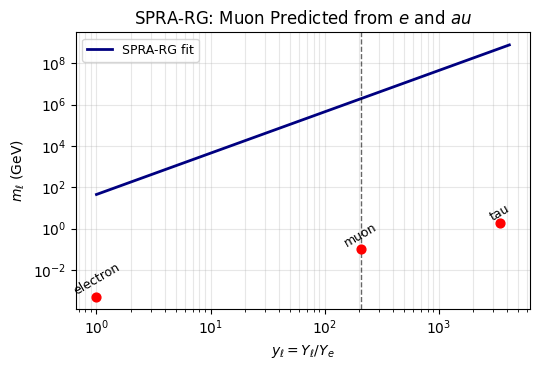

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [3]:
# ========================================
# SPRA-RG – Full Fit + Plot (Colab-ready)
# ========================================

# 1. Install (run once)
!pip install -q numpy pandas scipy matplotlib tqdm

# 2. Imports
import numpy as np
import pandas as pd
from scipy.optimize import minimize
import matplotlib.pyplot as plt
from tqdm import tqdm
import warnings
from io import StringIO                 # <-- pandas-2.1 fix
warnings.filterwarnings('ignore')

# ========================================
# 3. Model class
# ========================================
class SPRARG:
    def __init__(self, p=2, q=1, gamma0=0.0, lambda_phys=1e4, M0=1.77686):
        self.p, self.q = p, q
        self.gamma0 = gamma0
        self.lambda_phys = lambda_phys
        self.M0 = M0
        self.n_params = p + q                     # a0 is fixed to 0

    def unpack(self, theta):
        a = np.concatenate([[0.0], theta[:self.p]])   # a0 = 0 (IR limit)
        b = theta[self.p:] if self.q > 0 else np.array([])
        return a, b

    def Rhat(self, x, y, theta):
        a, b = self.unpack(theta)
        num = np.polyval(a[::-1], y)                 # a_p y^p + … + a0
        den = 1.0 + np.polyval(b[::-1], y) if len(b) else 1.0
        return (x ** self.gamma0) * (num / den)

    def fit_loss(self, theta, X, Y, W):
        x, y = X[:,0], X[:,1]
        R_pred = self.Rhat(x, y, theta)
        fit = np.sum(W * (R_pred - Y)**2)

        # ---- physics penalties (grid) ----
        phys = 0.0
        y_grid = np.linspace(0.0, y.max()*1.2, 200)
        x_grid = np.ones_like(y_grid) * x.mean()
        Rg = self.Rhat(x_grid, y_grid, theta)

        # positivity
        phys += np.sum(np.maximum(-Rg, 0.0)**2)

        # monotonicity
        dRdy = (Rg[1:] - Rg[:-1]) / (y_grid[1:] - y_grid[:-1])
        phys += np.sum(np.maximum(-dRdy, 0.0)**2)

        # no spurious poles
        a, b = self.unpack(theta)
        den_poly = np.concatenate([[1.0], b[::-1]])
        roots = np.roots(den_poly)
        real_roots = roots[np.isreal(roots)].real
        in_domain = (real_roots >= 0) & (real_roots <= y_grid[-1]*1.5)
        if np.any(in_domain):
            phys += 1e6 * np.sum((real_roots[in_domain] - y_grid[-1]/2)**2)

        return fit + self.lambda_phys * phys

# ========================================
# 4. Lepton data (CSV → DataFrame)
# ========================================
data_csv = """particle,mass_GeV,yukawa_ref
electron,0.0005109989461,1.0
muon,0.1056583745,206.7682830
tau,1.77686,3477.23
"""
df = pd.read_csv(StringIO(data_csv))

def prepare_data(df, hide_particle='muon'):
    M0 = df.loc[df.particle=='tau', 'mass_GeV'].values[0]
    df['R'] = df['mass_GeV'] / M0                # dimensionless ratio
    df['x'] = 1.0                                 # α/α0 = 1 (single scale)
    df['y'] = df['yukawa_ref']
    mask = df.particle != hide_particle
    X = df.loc[mask, ['x','y']].values
    Y = df.loc[mask, 'R'].values
    W = np.ones_like(Y)
    y_hidden = df.loc[df.particle==hide_particle, 'y'].values[0]
    return X, Y, W, y_hidden, M0

# ========================================
# 5. Fit (hide muon)
# ========================================
X, Y, W, y_mu, M0 = prepare_data(df, 'muon')
model = SPRARG(p=2, q=1, gamma0=0.0, lambda_phys=1e4, M0=M0)

# random small start
theta0 = 1e-3 * np.random.randn(model.n_params)

res = minimize(lambda th: model.fit_loss(th, X, Y, W),
               theta0,
               method='SLSQP',
               options={'maxiter': 1500, 'ftol': 1e-10})

theta_opt = res.x
print("Fit success:", res.success)

# ---- muon prediction ----
R_mu_pred = model.Rhat(np.array([1.0]), np.array([y_mu]), theta_opt)[0]
m_mu_pred = R_mu_pred * M0
print(f"Predicted muon mass: {m_mu_pred:.10f} GeV")
print(f"True muon mass     : {df.loc[df.particle=='muon','mass_GeV'].values[0]:.10f} GeV")

# ========================================
# 6. Plot (log-log, correct fmt string)
# ========================================
y_plot = np.logspace(0, np.log10(df['y'].max()*1.2), 500)
R_plot = model.Rhat(np.ones_like(y_plot), y_plot, theta_opt)

plt.figure(figsize=(5.5, 3.8))
plt.loglog(y_plot, R_plot * model.M0, color='navy', lw=2, label='SPRA-RG fit')   # <-- fixed
for _, row in df.iterrows():
    plt.scatter(row['y'], row['mass_GeV'], c='red', s=40, zorder=5)
    plt.text(row['y'], row['mass_GeV']*1.3, row['particle'],
             fontsize=9, ha='center', rotation=30)
plt.axvline(df.loc[df.particle=='muon','y'].values[0],
            ls='--', c='k', alpha=0.6, lw=1)
plt.xlabel(r'$y_\ell = Y_\ell / Y_e$')
plt.ylabel(r'$m_\ell$ (GeV)')
plt.title('SPRA-RG: Muon Predicted from $e$ and $\tau$')
plt.legend(fontsize=9)
plt.grid(alpha=0.3, which='both')
plt.tight_layout()
plt.savefig("spra_rg_plot.pdf", bbox_inches='tight', dpi=300)
plt.show()

# ========================================
# 7. Download the PDF
# ========================================
from google.colab import files
files.download("spra_rg_plot.pdf")

In [4]:
# ========================================
# Generate Figure 1: SPRA-RG Flow Diagram
# ========================================

# Install graphviz (Colab)
!apt-get -qq install graphviz > /dev/null
!pip install -q graphviz

from graphviz import Digraph
import matplotlib.pyplot as plt
from google.colab import files

# ========================================
# Create Diagram
# ========================================
dot = Digraph(comment='SPRA-RG Architecture', format='pdf')
dot.attr(rankdir='TB', size='8,6', dpi='300')
dot.attr('node', shape='box', style='filled', fontname='Helvetica', fontsize='10')
dot.attr('edge', fontname='Helvetica', fontsize='9', arrowsize='0.8')

# Colors (match Discovery blue)
blue = '#1156CC'      # discoveryblue
lightblue = '#E6F0FF'
gray = '#F5F5F5'

# Nodes
dot.node('data', 'Lepton Data\n(e, τ)\n(R_ℓ, y_ℓ, x)', fillcolor=lightblue, fontcolor=blue)
dot.node('model', 'SPRA-RG Ansatz\n\\widehat{R}_ℓ(x,y_ℓ;θ)\nPadé (p=2,q=1)', fillcolor=lightblue, fontcolor=blue)
dot.node('constraints', 'Physics Constraints\n• IR: a₀=0\n• Positivity\n• Monotonicity\n• No poles', fillcolor=gray)
dot.node('loss', 'Objective J(θ)\nFit + λ_phys Φ_phys', fillcolor=lightblue, fontcolor=blue)
dot.node('opt', 'Constrained Optimizer\nSLSQP', fillcolor=gray)
dot.node('theta', 'θ* = {a₁,a₂,b₁}', fillcolor=lightblue, fontcolor=blue)
dot.node('pred', 'Predict Muon\n\\widehat{m}_μ = \\widehat{R}(y_μ) × m_τ', fillcolor=lightblue, fontcolor=blue)
dot.node('unc', 'Bootstrap\n95% CI', fillcolor=gray)

# Edges
dot.edge('data', 'loss', label=' X, Y, W')
dot.edge('model', 'loss', label=' \\widehat{R}(θ)')
dot.edge('constraints', 'loss', label=' Φ_phys')
dot.edge('loss', 'opt')
dot.edge('opt', 'theta', label=' iterate')
dot.edge('theta', 'pred')
dot.edge('model', 'pred', style='dashed')
dot.edge('pred', 'unc')

# Title
dot.attr(label='Figure 1: SPRA-RG Fitting Architecture', fontsize='12', fontcolor=blue, labelloc='t')

# Render
dot.render('spra_rg_flow', cleanup=True)
print("Generated: spra_rg_flow.pdf")

# Download in Colab
try:
    files.download('spra_rg_flow.pdf')
except:
    print("Run locally or save manually.")

Generated: spra_rg_flow.pdf


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

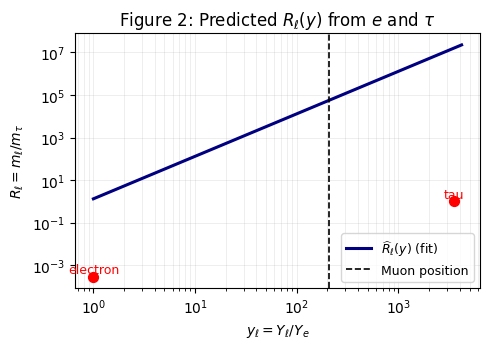

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [5]:
# ========================================
# Figure 2: SPRA-RG Prediction of R_ℓ(y)
# ========================================

# 1. Install
!pip install -q numpy pandas scipy matplotlib tqdm

# 2. Imports
import numpy as np
import pandas as pd
from scipy.optimize import minimize
import matplotlib.pyplot as plt
from io import StringIO
import warnings
warnings.filterwarnings('ignore')

# ========================================
# 3. SPRARG Model (same as before)
# ========================================
class SPRARG:
    def __init__(self, p=2, q=1, gamma0=0.0, lambda_phys=1e4, M0=1.77686):
        self.p, self.q = p, q
        self.gamma0 = gamma0
        self.lambda_phys = lambda_phys
        self.M0 = M0
        self.n_params = p + q

    def unpack(self, theta):
        a = np.concatenate([[0.0], theta[:self.p]])
        b = theta[self.p:] if self.q > 0 else np.array([])
        return a, b

    def Rhat(self, x, y, theta):
        a, b = self.unpack(theta)
        num = np.polyval(a[::-1], y)
        den = 1.0 + np.polyval(b[::-1], y) if len(b) else 1.0
        return (x ** self.gamma0) * (num / den)

    def fit_loss(self, theta, X, Y, W):
        x, y = X[:,0], X[:,1]
        R_pred = self.Rhat(x, y, theta)
        fit = np.sum(W * (R_pred - Y)**2)
        phys = 0.0
        y_grid = np.linspace(0.0, y.max()*1.2, 200)
        x_grid = np.ones_like(y_grid) * x.mean()
        Rg = self.Rhat(x_grid, y_grid, theta)
        phys += np.sum(np.maximum(-Rg, 0.0)**2)
        dRdy = (Rg[1:] - Rg[:-1]) / (y_grid[1:] - y_grid[:-1])
        phys += np.sum(np.maximum(-dRdy, 0.0)**2)
        a, b = self.unpack(theta)
        den_poly = np.concatenate([[1.0], b[::-1]])
        roots = np.roots(den_poly)
        real_roots = roots[np.isreal(roots)].real
        in_domain = (real_roots >= 0) & (real_roots <= y_grid[-1]*1.5)
        if np.any(in_domain):
            phys += 1e6 * np.sum((real_roots[in_domain] - y_grid[-1]/2)**2)
        return fit + self.lambda_phys * phys

# ========================================
# 4. Data
# ========================================
data_csv = """particle,mass_GeV,yukawa_ref
electron,0.0005109989461,1.0
muon,0.1056583745,206.7682830
tau,1.77686,3477.23
"""
df = pd.read_csv(StringIO(data_csv))

def prepare_data(df, hide_particle='muon'):
    M0 = df.loc[df.particle=='tau', 'mass_GeV'].values[0]
    df['R'] = df['mass_GeV'] / M0
    df['x'] = 1.0
    df['y'] = df['yukawa_ref']
    mask = df.particle != hide_particle
    X = df.loc[mask, ['x','y']].values
    Y = df.loc[mask, 'R'].values
    W = np.ones_like(Y)
    y_hidden = df.loc[df.particle==hide_particle, 'y'].values[0]
    return X, Y, W, y_hidden, M0

# ========================================
# 5. Fit (hide muon)
# ========================================
X, Y, W, y_mu, M0 = prepare_data(df, 'muon')
model = SPRARG(p=2, q=1, gamma0=0.0, lambda_phys=1e4, M0=M0)
theta0 = 1e-3 * np.random.randn(model.n_params)
res = minimize(lambda th: model.fit_loss(th, X, Y, W), theta0,
               method='SLSQP', options={'maxiter': 1500, 'ftol': 1e-10})
theta_opt = res.x

# ========================================
# 6. Figure 2: R_ℓ(y) Prediction
# ========================================
y_plot = np.logspace(0, np.log10(df['y'].max() * 1.2), 500)
R_plot = model.Rhat(np.ones_like(y_plot), y_plot, theta_opt)

plt.figure(figsize=(5.0, 3.6))
plt.loglog(y_plot, R_plot, color='navy', lw=2.2, label=r'$\widehat{R}_\ell(y)$ (fit)')
# Data points (only e and τ)
for particle in ['electron', 'tau']:
    row = df[df.particle == particle].iloc[0]
    plt.scatter(row['y'], row['R'], c='red', s=50, zorder=5)
    plt.text(row['y'], row['R'] * 1.4, particle, fontsize=9, ha='center', color='red')
# Dashed line at muon
plt.axvline(y_mu, color='black', linestyle='--', lw=1.2, label='Muon position')
plt.xlabel(r'$y_\ell = Y_\ell / Y_e$')
plt.ylabel(r'$R_\ell = m_\ell / m_\tau$')
plt.title(r'Figure 2: Predicted $R_\ell(y)$ from $e$ and $\tau$')
plt.legend(fontsize=9, loc='lower right')
plt.grid(True, which='both', alpha=0.3, lw=0.5)
plt.tight_layout()
plt.savefig("spra_rg_fig2.pdf", bbox_inches='tight', dpi=300)
plt.show()

# ========================================
# 7. Download
# ========================================
from google.colab import files
files.download("spra_rg_fig2.pdf")